<a href="https://colab.research.google.com/github/Elvinaade/Dashboard_Prediksi_Saham_LSTM_fixed/blob/main/EDA_Risosbis_DATA_SURVEI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)
## Survei Kepuasan Pengunjung — RTH Bungkul Surabaya

Notebook ini melakukan EDA terhadap data pada sheet **`DATA SURVEI`** dari file Excel hasil rekap survei.

**Variabel yang dianalisis:**
1. Jenis Kelamin
2. Usia Pengunjung
3. Pendidikan Terakhir
4. Frekuensi Kunjungan dalam 1 Bulan
5. Durasi Waktu Berkunjung
6. Kepuasan Pengunjung

**Klasifikasi variabel:**
- **Kategorik** → Jenis Kelamin, Pendidikan Terakhir, Kepuasan Pengunjung (skala Likert 1–6, diperlakukan ordinal-kategorik) → Bar Chart & Pie Chart
- **Numerik** → Usia, Frekuensi Kunjungan, Durasi Waktu Berkunjung → Histogram & Boxplot

---

In [ ]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import warnings

warnings.filterwarnings('ignore')

# Pengaturan tampilan & gaya visualisasi
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

# Palet warna konsisten & profesional (dipakai di seluruh visualisasi)
PALET_KATEGORIK = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#6D6875']
WARNA_NUMERIK   = '#2A9D8F'
WARNA_AKSEN     = '#E76F51'

print('Seluruh library berhasil di-import.')

Seluruh library berhasil di-import.


## 1. Upload & Membaca Data

Jalankan sel berikut untuk mengunggah file Excel (`.xlsx`), lalu data akan dibaca dari sheet **`DATA SURVEI`**.

In [ ]:
# ============================================================
# 2. UPLOAD FILE EXCEL
# ============================================================
from google.colab import files

print('Silakan pilih file Excel (.xlsx) yang ingin dianalisis...')
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]
print(f'\nFile "{nama_file}" berhasil diunggah.')

Silakan pilih file Excel (.xlsx) yang ingin dianalisis...


Saving Karakteristik Risos.xlsx to Karakteristik Risos.xlsx

File "Karakteristik Risos.xlsx" berhasil diunggah.


In [ ]:
# ============================================================
# 3. MEMBACA DATA DARI SHEET "DATA SURVEI"
# ============================================================
NAMA_SHEET = 'DATA SURVEI'

df = pd.read_excel(nama_file, sheet_name=NAMA_SHEET)

print(f'Data berhasil dibaca dari sheet "{NAMA_SHEET}".')
print(f'   Jumlah baris : {df.shape[0]}')
print(f'   Jumlah kolom : {df.shape[1]}')

Data berhasil dibaca dari sheet "DATA SURVEI".
   Jumlah baris : 71
   Jumlah kolom : 6


## 2. Gambaran Umum Data

In [ ]:
# ----- 5 Baris Pertama -----
df.head()

,Jenis Kelamin,Usia,Pendidikan Terakhir yang Ditama,Frekuensi Kunjungan dalam 1 Bul,Durasi Waktu di RTH Bungkul (ja,Kepuasan Pengunjung
0,Perempuan,14,SD/MI/Sederajat,1,3.0,Puas
1,Perempuan,15,SMP/MTS/Sederajat,1,2.0,Puas
2,Perempuan,18,SMA/SMK/Sederajat,2,2.0,Tidak Puas
3,Laki-laki,19,SMA/SMK/Sederajat,1,2.0,Tidak Puas
4,Laki-laki,18,SMA/SMK/Sederajat,1,1.0,Puas


In [ ]:
# ----- Informasi Struktur Data -----
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Jenis Kelamin                    71 non-null     object 
 1   Usia                             71 non-null     int64  
 2   Pendidikan Terakhir yang Ditama  71 non-null     object 
 3   Frekuensi Kunjungan dalam 1 Bul  71 non-null     int64  
 4   Durasi Waktu di RTH Bungkul (ja  71 non-null     float64
 5   Kepuasan Pengunjung              71 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 3.5+ KB


In [ ]:
# ----- Ukuran Data & Nama Kolom -----
print(f'Ukuran data : {df.shape[0]} baris x {df.shape[1]} kolom\n')
print('Daftar nama kolom:')
for i, kol in enumerate(df.columns, 1):
    print(f'{i:>2}. {kol}')

Ukuran data : 71 baris x 6 kolom

Daftar nama kolom:
 1. Jenis Kelamin
 2. Usia
 3. Pendidikan Terakhir yang Ditama
 4. Frekuensi Kunjungan dalam 1 Bul
 5. Durasi Waktu di RTH Bungkul (ja
 6. Kepuasan Pengunjung


In [ ]:
# ----- Pengecekan Missing Value -----
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
tabel_missing = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
tabel_missing = tabel_missing[tabel_missing['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

if tabel_missing.empty:
    print('Tidak ditemukan missing value pada seluruh kolom data.')
else:
    print('Kolom dengan missing value:')
    display(tabel_missing)

Tidak ditemukan missing value pada seluruh kolom data.


## 3. Definisi Variabel Utama & Fungsi Bantu

Nama kolom pada data survei cukup panjang, sehingga didefinisikan ulang ke dalam variabel singkat agar kode lebih rapi.
Dua fungsi bantu dibuat agar proses analisis (tabel frekuensi, visualisasi, dan interpretasi otomatis) konsisten untuk setiap variabel.

In [ ]:
# ============================================================
# 4. DEFINISI KOLOM VARIABEL UTAMA
# ============================================================
KOL_JENIS_KELAMIN = 'Jenis Kelamin'
KOL_USIA          = 'Usia'
KOL_PENDIDIKAN    = 'Pendidikan Terakhir yang Ditama'
KOL_FREKUENSI     = 'Frekuensi Kunjungan dalam 1 Bul'
KOL_DURASI        = 'Durasi Waktu di RTH Bungkul (ja'
KOL_KEPUASAN      = 'Kepuasan Pengunjung'

kolom_wajib = [KOL_JENIS_KELAMIN, KOL_USIA, KOL_PENDIDIKAN, KOL_FREKUENSI, KOL_DURASI, KOL_KEPUASAN]
kolom_tidak_ditemukan = [k for k in kolom_wajib if k not in df.columns]

if kolom_tidak_ditemukan:
    print('Kolom berikut tidak ditemukan pada data, periksa kembali nama kolom:')
    for k in kolom_tidak_ditemukan:
        print('   -', k)
else:
    print('Seluruh kolom variabel utama berhasil ditemukan pada data.')

Seluruh kolom variabel utama berhasil ditemukan pada data.


In [ ]:
# ============================================================
# 5. FUNGSI BANTU: ANALISIS VARIABEL KATEGORIK
# ============================================================
def analisis_variabel_kategorik(data, kolom, label, urutan=None):
    nilai = data[kolom].dropna()
    freq = nilai.value_counts()
    if urutan is not None:
        freq = freq.reindex(urutan).dropna()
    pct = (freq / freq.sum() * 100).round(2)

    tabel = pd.DataFrame({'Frekuensi': freq.astype(int), 'Persentase (%)': pct})
    print(f'\n{"="*72}\nTabel Frekuensi - {label}\n{"="*72}')
    display(tabel)

    warna = (PALET_KATEGORIK * (len(freq)//len(PALET_KATEGORIK)+1))[:len(freq)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # --- Bar chart ---
    bars = axes[0].bar(freq.index.astype(str), freq.values, color=warna, edgecolor='white', linewidth=1)
    axes[0].set_title(f'Distribusi {label}', fontsize=13)
    axes[0].set_xlabel(label, fontsize=11)
    axes[0].set_ylabel('Jumlah Responden', fontsize=11)
    axes[0].tick_params(axis='x', rotation=15)
    axes[0].set_ylim(0, freq.values.max() * 1.22)
    for bar, n, p in zip(bars, freq.values, pct.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + freq.values.max()*0.02,
                     f'{n}\n({p}%)', ha='center', va='bottom', fontsize=9.5)

    # --- Pie chart + legenda ---
    wedges, _, autotexts = axes[1].pie(
        freq.values, autopct='%1.1f%%', colors=warna, startangle=90, pctdistance=0.7,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.3},
        textprops={'fontsize': 10, 'color': 'white', 'fontweight': 'bold'}
    )
    legend_labels = [f'{cat}  ({n} | {p}%)' for cat, n, p in zip(freq.index.astype(str), freq.values, pct.values)]
    axes[1].legend(wedges, legend_labels, title=label, loc='center left',
                   bbox_to_anchor=(1.02, 0.5), fontsize=9.5, title_fontsize=10, frameon=False)
    axes[1].set_title(f'Proporsi {label}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # --- Interpretasi otomatis ---
    kat_dominan, pct_dominan = freq.idxmax(), pct.max()
    kat_minor, pct_minor = freq.idxmin(), pct.min()
    print('Interpretasi:')
    print(f'   - Mayoritas responden berada pada kategori "{kat_dominan}" yaitu sebanyak '
          f'{freq.max()} orang ({pct_dominan}% dari total responden).')
    if len(freq) > 1:
        print(f'   - Kategori dengan jumlah responden paling sedikit adalah "{kat_minor}" '
              f'({freq.min()} orang / {pct_minor}%).')
        print(f'   - Variabel ini memiliki {len(freq)} kategori berbeda.')

    return tabel

In [ ]:
# ============================================================
# 6. FUNGSI BANTU: ANALISIS VARIABEL NUMERIK
# ============================================================
def analisis_variabel_numerik(data, kolom, label, satuan=''):
    nilai = data[kolom].dropna()

    deskripsi = nilai.describe()
    print(f'\n{"="*72}\nStatistik Deskriptif - {label}\n{"="*72}')
    display(deskripsi.to_frame('Nilai').round(2))

    mean_v, median_v, std_v, skew_v = nilai.mean(), nilai.median(), nilai.std(), nilai.skew()
    q1, q3 = nilai.quantile(0.25), nilai.quantile(0.75)
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = nilai[(nilai < batas_bawah) | (nilai > batas_atas)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Histogram ---
    diskrit = nilai.nunique() <= 15
    sns.histplot(nilai, kde=True, ax=axes[0], color=WARNA_NUMERIK, edgecolor='white', discrete=diskrit)
    axes[0].axvline(mean_v, color='#E76F51', linestyle='--', linewidth=1.6, label=f'Rata-rata: {mean_v:.2f}')
    axes[0].axvline(median_v, color='#264653', linestyle=':', linewidth=1.8, label=f'Median: {median_v:.2f}')
    axes[0].set_title(f'Histogram {label}', fontsize=13)
    axes[0].set_xlabel(f'{label} {satuan}'.strip(), fontsize=11)
    axes[0].set_ylabel('Frekuensi', fontsize=11)
    axes[0].legend(fontsize=9)

    # --- Boxplot ---
    sns.boxplot(x=nilai, ax=axes[1], color=WARNA_NUMERIK, fliersize=6, width=0.45,
                flierprops={'markerfacecolor': '#E76F51', 'markeredgecolor': '#E76F51', 'markersize': 6},
                showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': '#FFD166',
                           'markeredgecolor': '#264653', 'markersize': 8, 'zorder': 5})

    axes[1].set_ylim(-0.85, 1.15)

    # Label Q1, Median, Q3 di bawah kotak
    axes[1].annotate(f'Q1={q1:.1f}', xy=(q1, -0.225), xytext=(q1, -0.42),
                      ha='center', va='top', fontsize=8.5, color='#264653')
    axes[1].annotate(f'Median={median_v:.1f}', xy=(median_v, -0.225), xytext=(median_v, -0.55),
                      ha='center', va='top', fontsize=8.5, color='#264653', fontweight='bold')
    axes[1].annotate(f'Q3={q3:.1f}', xy=(q3, -0.225), xytext=(q3, -0.42),
                      ha='center', va='top', fontsize=8.5, color='#264653')

    # Label Mean di atas kotak
    axes[1].annotate(f'Mean={mean_v:.2f}', xy=(mean_v, 0.225), xytext=(mean_v, 0.40),
                      ha='center', va='bottom', fontsize=8.5, color='#A0590B', fontweight='bold')

    # Label nilai tiap outlier (nilai unik; jika berdekatan, ditumpuk bertingkat agar tidak tabrakan)
    if len(outliers) > 0:
        nilai_unik = sorted(outliers.unique())
        rentang = (nilai.max() - nilai.min()) or 1
        ambang = rentang * 0.06
        tier_y = [0.62, 0.80, 0.98]
        tier_idx, x_sebelumnya = 0, None
        for val in nilai_unik:
            tier_idx = 0 if (x_sebelumnya is None or (val - x_sebelumnya) >= ambang) else tier_idx + 1
            tier_idx = min(tier_idx, len(tier_y) - 1)
            jumlah = (outliers == val).sum()
            teks = f'{val:.0f}' if float(val).is_integer() else f'{val:.1f}'
            if jumlah > 1:
                teks += f' (x{jumlah})'
            axes[1].annotate(teks, xy=(val, 0.10), xytext=(val, tier_y[tier_idx]),
                              ha='center', va='bottom', fontsize=8, color='#E76F51',
                              arrowprops=dict(arrowstyle='-', color='#E76F51', lw=0.7, alpha=0.6))
            x_sebelumnya = val

    axes[1].set_title(f'Boxplot {label}', fontsize=13)
    axes[1].set_xlabel(f'{label} {satuan}'.strip(), fontsize=11)
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

    # --- Interpretasi otomatis ---
    if abs(skew_v) < 0.5:
        bentuk = 'relatif simetris (mendekati distribusi normal)'
    elif skew_v > 0:
        bentuk = 'menceng ke kanan (sebagian kecil responden memiliki nilai tinggi yang menarik rata-rata ke atas)'
    else:
        bentuk = 'menceng ke kiri (sebagian kecil responden memiliki nilai rendah yang menarik rata-rata ke bawah)'

    print('Interpretasi:')
    print(f'   - Rata-rata {label} adalah {mean_v:.2f} {satuan}, dengan median {median_v:.2f} {satuan} '
          f'dan standar deviasi {std_v:.2f}.')
    print(f'   - Bentuk distribusi data {bentuk} (skewness = {skew_v:.2f}).')
    print(f'   - Rentang data: {nilai.min()} - {nilai.max()} {satuan}.')
    if len(outliers) > 0:
        print(f'   - Terdeteksi {len(outliers)} outlier (di luar rentang {batas_bawah:.2f}-{batas_atas:.2f}) '
              f'berdasarkan metode IQR.')
    else:
        print('   - Tidak terdeteksi outlier yang signifikan pada variabel ini.')

    return deskripsi

## 4. Analisis Per Variabel

### 4.1 Jenis Kelamin


Tabel Frekuensi - Jenis Kelamin


,Frekuensi,Persentase (%)
Jenis Kelamin,,
Perempuan,39,54.93
Laki-laki,32,45.07


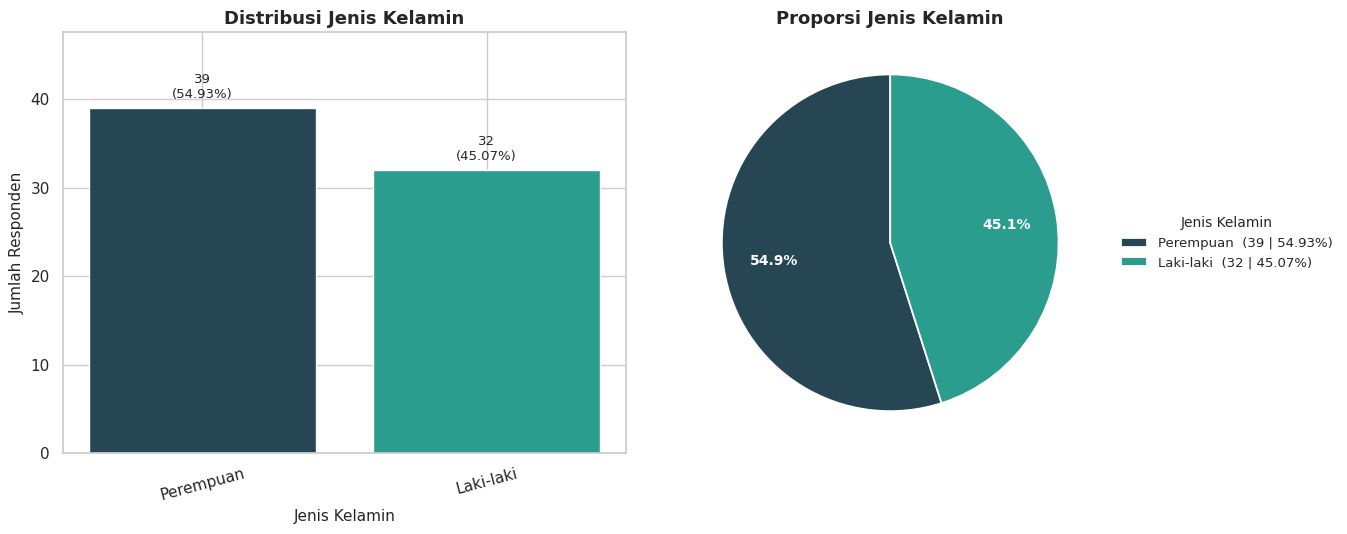

Interpretasi:
   - Mayoritas responden berada pada kategori "Perempuan" yaitu sebanyak 39 orang (54.93% dari total responden).
   - Kategori dengan jumlah responden paling sedikit adalah "Laki-laki" (32 orang / 45.07%).
   - Variabel ini memiliki 2 kategori berbeda.


In [ ]:
_ = analisis_variabel_kategorik(df, KOL_JENIS_KELAMIN, 'Jenis Kelamin')

### 4.2 Usia Pengunjung


Statistik Deskriptif - Usia Pengunjung


,Nilai
count,71.00
mean,24.31
std,7.78
min,14.00
25%,20.00
50%,22.00
75%,25.50
max,57.00


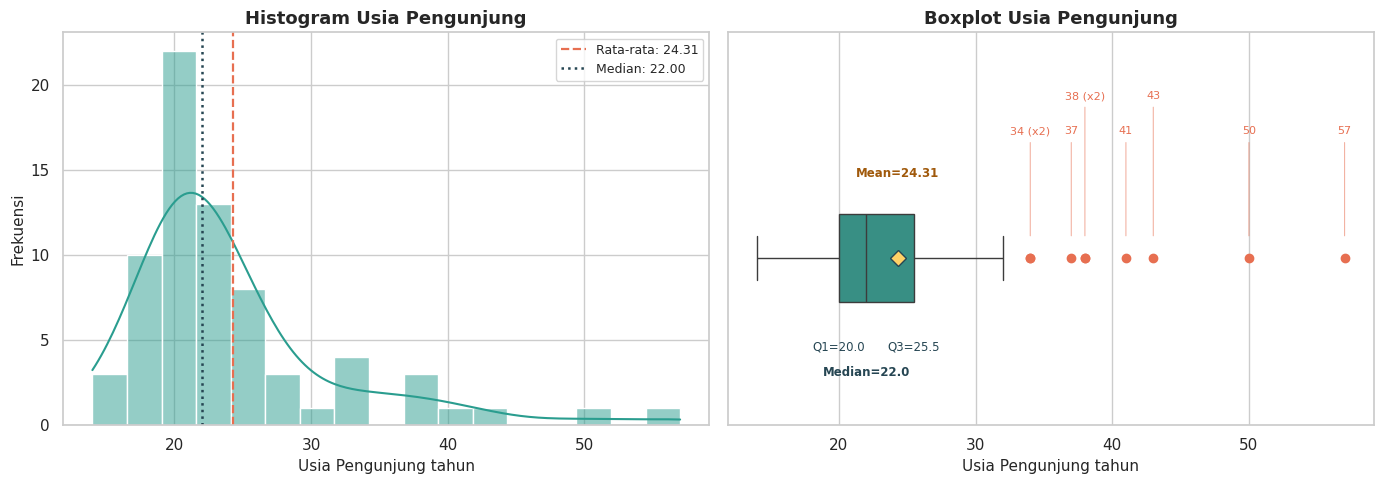

Interpretasi:
   - Rata-rata Usia Pengunjung adalah 24.31 tahun, dengan median 22.00 tahun dan standar deviasi 7.78.
   - Bentuk distribusi data menceng ke kanan (sebagian kecil responden memiliki nilai tinggi yang menarik rata-rata ke atas) (skewness = 2.09).
   - Rentang data: 14 - 57 tahun.
   - Terdeteksi 9 outlier (di luar rentang 11.75-33.75) berdasarkan metode IQR.


In [ ]:
_ = analisis_variabel_numerik(df, KOL_USIA, 'Usia Pengunjung', satuan='tahun')

### 4.3 Pendidikan Terakhir


Tabel Frekuensi - Pendidikan Terakhir


,Frekuensi,Persentase (%)
Pendidikan Terakhir yang Ditama,,
SD/MI/Sederajat,2,2.82
SMP/MTS/Sederajat,3,4.23
SMA/SMK/Sederajat,42,59.15
Diploma,7,9.86
Sarjana,16,22.54
Pasca Sarjana,1,1.41


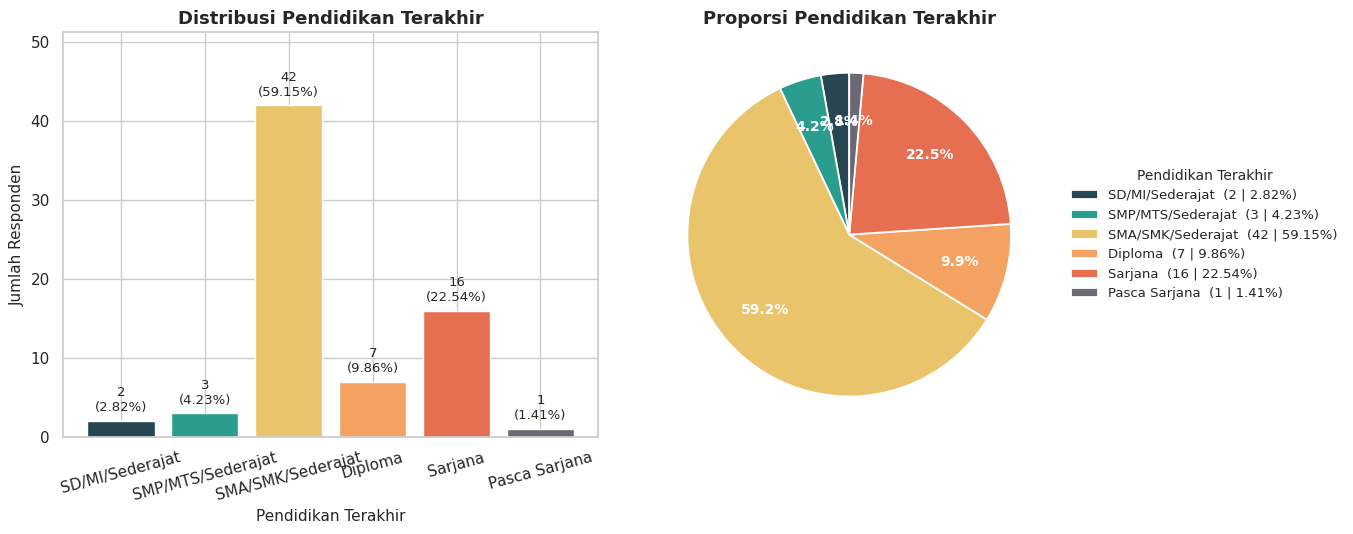

Interpretasi:
   - Mayoritas responden berada pada kategori "SMA/SMK/Sederajat" yaitu sebanyak 42 orang (59.15% dari total responden).
   - Kategori dengan jumlah responden paling sedikit adalah "Pasca Sarjana" (1 orang / 1.41%).
   - Variabel ini memiliki 6 kategori berbeda.


In [ ]:
urutan_pendidikan = ['SD/MI/Sederajat', 'SMP/MTS/Sederajat', 'SMA/SMK/Sederajat',
                      'Diploma', 'Sarjana', 'Pasca Sarjana']
urutan_valid = [u for u in urutan_pendidikan if u in df[KOL_PENDIDIKAN].unique()]
sisanya = [u for u in df[KOL_PENDIDIKAN].unique() if u not in urutan_valid]
urutan_final = urutan_valid + sisanya

_ = analisis_variabel_kategorik(df, KOL_PENDIDIKAN, 'Pendidikan Terakhir', urutan=urutan_final)

### 4.4 Frekuensi Kunjungan dalam 1 Bulan


Statistik Deskriptif - Frekuensi Kunjungan per Bulan


,Nilai
count,71.00
mean,2.15
std,1.08
min,1.00
25%,1.00
50%,2.00
75%,3.00
max,5.00


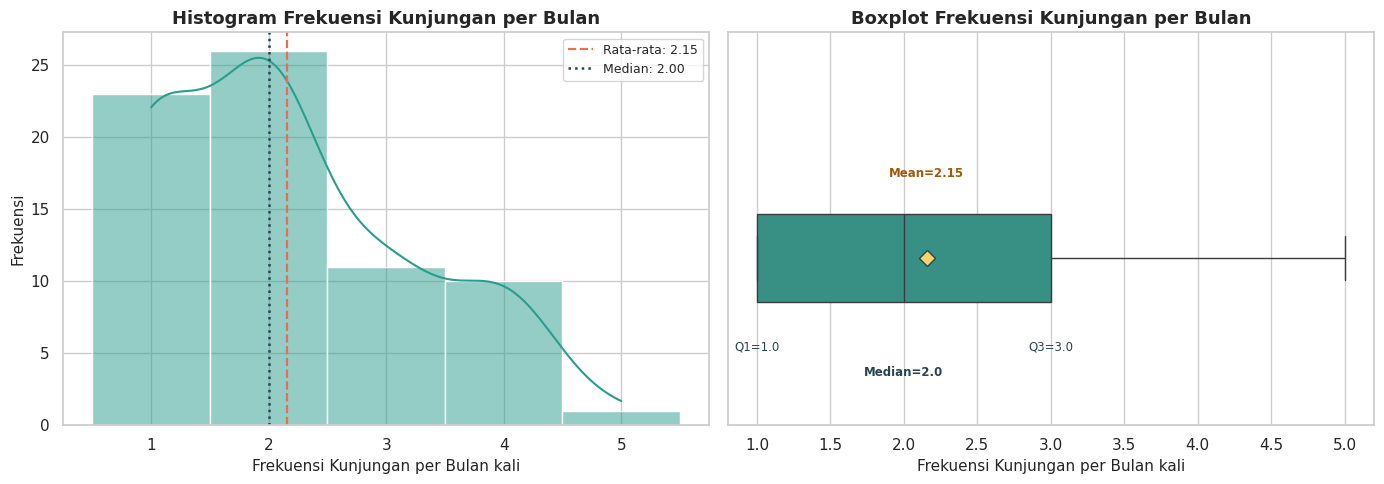

Interpretasi:
   - Rata-rata Frekuensi Kunjungan per Bulan adalah 2.15 kali, dengan median 2.00 kali dan standar deviasi 1.08.
   - Bentuk distribusi data menceng ke kanan (sebagian kecil responden memiliki nilai tinggi yang menarik rata-rata ke atas) (skewness = 0.67).
   - Rentang data: 1 - 5 kali.
   - Tidak terdeteksi outlier yang signifikan pada variabel ini.


In [ ]:
_ = analisis_variabel_numerik(df, KOL_FREKUENSI, 'Frekuensi Kunjungan per Bulan', satuan='kali')


Tabel Frekuensi - Frekuensi Kunjungan per Bulan


,Frekuensi,Persentase (%)
Frekuensi Kunjungan dalam 1 Bul,,
1,23,32.39
2,26,36.62
3,11,15.49
4,10,14.08
5,1,1.41


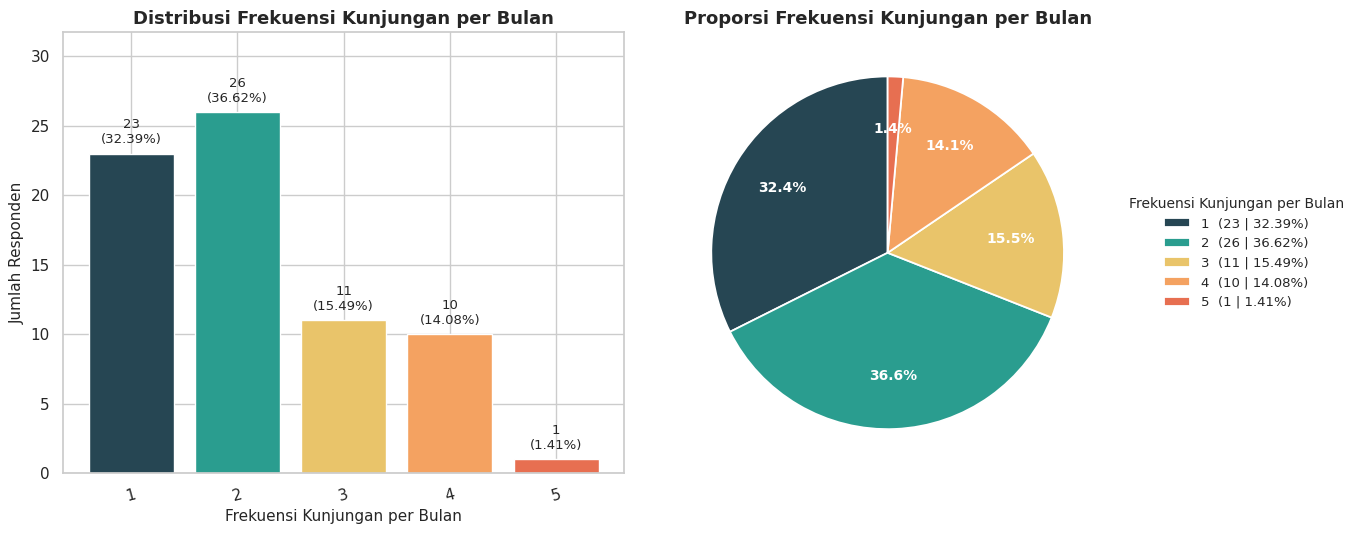

Interpretasi:
   - Mayoritas responden berada pada kategori "2" yaitu sebanyak 26 orang (36.62% dari total responden).
   - Kategori dengan jumlah responden paling sedikit adalah "5" (1 orang / 1.41%).
   - Variabel ini memiliki 5 kategori berbeda.


In [ ]:
urutan_frekuensi = sorted(df[KOL_FREKUENSI].dropna().unique())
_ = analisis_variabel_kategorik(df, KOL_FREKUENSI, 'Frekuensi Kunjungan per Bulan', urutan=urutan_frekuensi)

### 4.5 Durasi Waktu Berkunjung


Statistik Deskriptif - Durasi Waktu Berkunjung


,Nilai
count,71.00
mean,2.50
std,0.88
min,1.00
25%,2.00
50%,2.50
75%,3.00
max,6.00


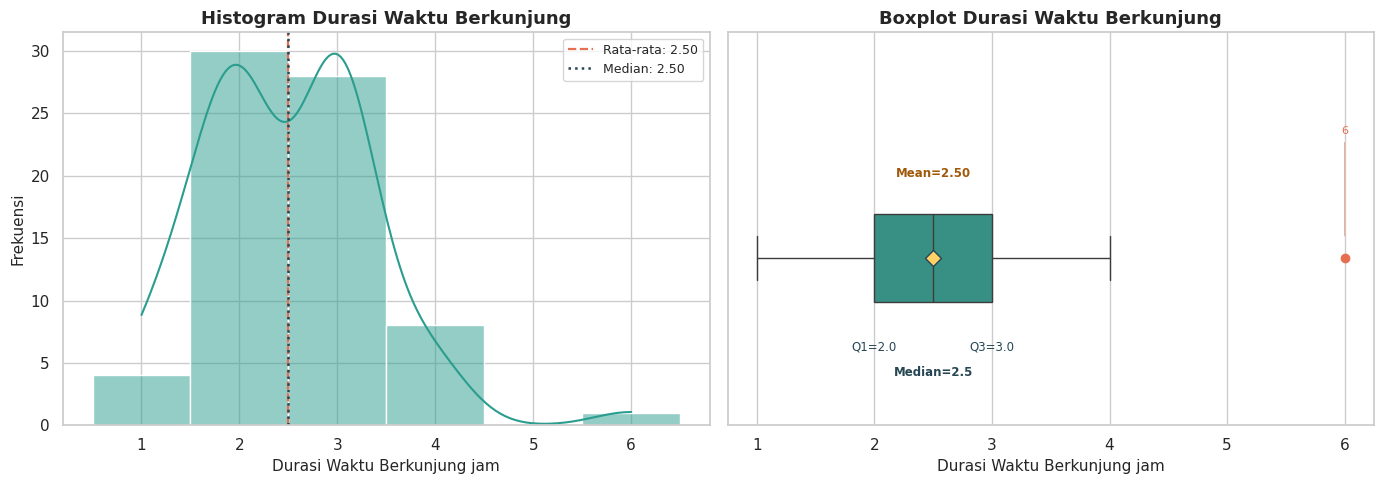

Interpretasi:
   - Rata-rata Durasi Waktu Berkunjung adalah 2.50 jam, dengan median 2.50 jam dan standar deviasi 0.88.
   - Bentuk distribusi data menceng ke kanan (sebagian kecil responden memiliki nilai tinggi yang menarik rata-rata ke atas) (skewness = 0.82).
   - Rentang data: 1.0 - 6.0 jam.
   - Terdeteksi 1 outlier (di luar rentang 0.50-4.50) berdasarkan metode IQR.


In [ ]:
_ = analisis_variabel_numerik(df, KOL_DURASI, 'Durasi Waktu Berkunjung', satuan='jam')

### 4.6 Kepuasan Pengunjung

Variabel ini berupa skala Likert 1–6 (kondisi nyata/*kenyataan*), sehingga diperlakukan sebagai variabel **ordinal-kategorik** agar lebih mudah diinterpretasikan dalam bentuk Bar Chart & Pie Chart.


Tabel Frekuensi - Kepuasan Pengunjung (Skala 1-6)


,Frekuensi,Persentase (%)
Kepuasan Pengunjung,,
Puas,56,78.87
Tidak Puas,15,21.13


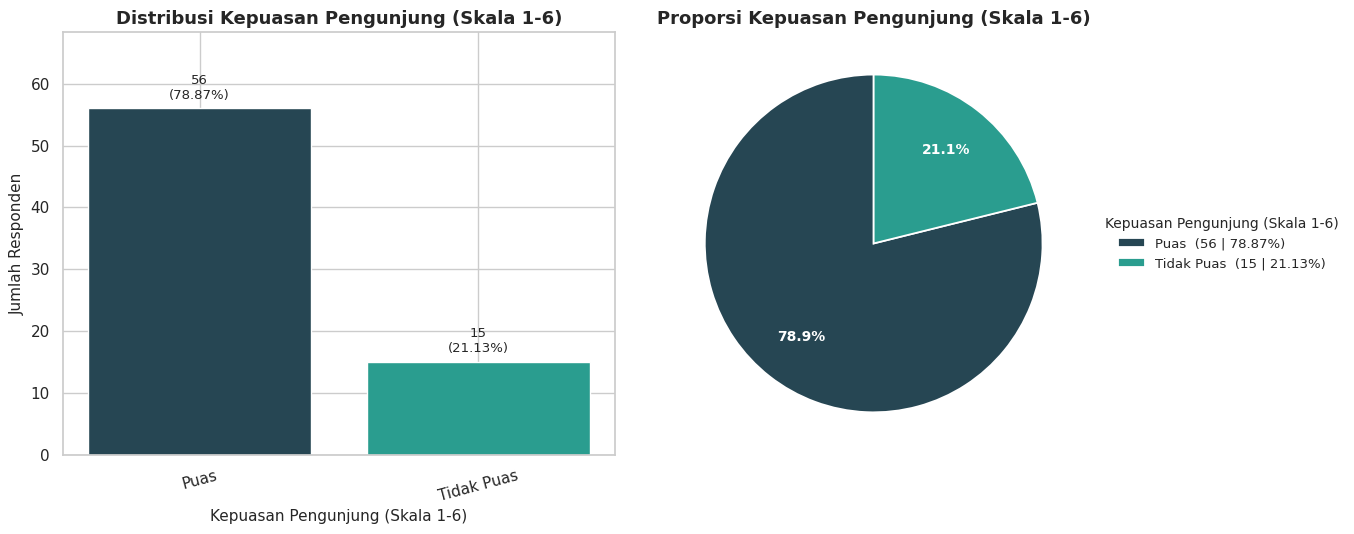

Interpretasi:
   - Mayoritas responden berada pada kategori "Puas" yaitu sebanyak 56 orang (78.87% dari total responden).
   - Kategori dengan jumlah responden paling sedikit adalah "Tidak Puas" (15 orang / 21.13%).
   - Variabel ini memiliki 2 kategori berbeda.


In [ ]:
urutan_kepuasan = sorted(df[KOL_KEPUASAN].dropna().unique())
_ = analisis_variabel_kategorik(df, KOL_KEPUASAN, 'Kepuasan Pengunjung (Skala 1-6)', urutan=urutan_kepuasan)

## Selesai

Notebook ini telah menyajikan EDA untuk variabel **Jenis Kelamin, Usia, Pendidikan Terakhir, Frekuensi Kunjungan, Durasi Waktu Berkunjung,** dan **Kepuasan Pengunjung**, lengkap dengan tabel frekuensi, visualisasi (bar chart, pie chart, histogram, boxplot), serta interpretasi otomatis pada setiap variabel.